<a href="https://colab.research.google.com/github/ISL-0111/XAI_AIPI590.01_2025Fall/blob/main/Week11_Mechanistic_Interpretability_Shawn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mechanistic Interpretability Assignment
**Name: Shawn(Ilseop) Lee**

----

Instructions
➡️ We have provided a starter notebook here: https://github.com/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/mechanistic_interp_starter.ipynb Links to an external site.

Note: you must use the starter as just that - a starter. You will need to create your own model, task, and methods for this assignment.





**Part 1 – Setup (Train Your Own Tiny Model on a Tiny Task)**
Build and train your own tiny model on a toy task. This should be something simple that trains in under 10 minutes, such as: XOR or parity classification, Reversing short sequences, Any other small, interpretable task you invent

**Part 2 – Explore**
Dive into the internals of your model. Consider the following: Inspect weights, activations, or attention maps
Try changing the input and observing how the internal state (e.g., hidden layer activations) responds.
Identify at least one neuron, attention head, or component that seems to be doing something meaningful.
Focus on forming a mechanistic hypothesis: What does this part of the model "care about"? What feature is it detecting or encoding?

**Part 3 – Explain**
Turn your observations into a story.
Write a clear, concise explanation of what you believe one part of the model is doing.
Use visuals (plots, heatmaps, diagrams) to support your explanation. Present this like a mini "computational case study" — tell us what the neuron or head is doing and why you think so.

**Part 4 – Reflect**
Include a short written reflection:
What did you learn about how your model works?
What was confusing, surprising, or challenging to interpret?
What’s one thing you wish you could understand better or explore further?

----

#### **Part 1 – Setup**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

In [ ]:
# Data Genearation for Binary Counting Task
def generate_parity_data(n_samples=10000, seq_length=8):
    X = []
    y = []
    for _ in range(n_samples):
        binary_str = [random.choice([0, 1]) for _ in range(seq_length)]
        # XOR of all bits == parity
        parity = sum(binary_str) % 2   # 0 if even, 1 if odd
        X.append(binary_str)
        y.append(parity)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

seq_length = 8
X_train, y_train = generate_parity_data(2000, seq_length)
X_val, y_val = generate_parity_data(500, seq_length)

**Build a Tiny MLP(Multilayer Perceptron) Model - Parity Classification**
- Task: Parity Classification (Even/Odd Detection)
- Input/Output: Binary Vector (Sequence length = 8) / Binary Label (0 or 1)
- Configuration : 2 Hidden Layers (16 -> 8 neurons)
- Activation: tanh (hidden), Sigmoid (output)
- Loss function: Binary-Cross Entropy
- Optimizer: Adam (lr = 0.005)
- Result: This two-layer MLP learned to classify 8-bit inputs by their parity. The Binary Cross-Entropy loss decreased from 0.69 to 0.18 over 300 epochs, and validation accuracy reached 91.2%. This shows that the model successfully captured most of the nonlinear XOR-like structure in the data. The loss curve stabilized after about 200 epochs, indicating convergence to a consistent internal representation of the parity rule.

ParityMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (activation): Sigmoid()
)
Epoch [50/300]  Loss: 0.6913
Epoch [100/300]  Loss: 0.6819
Epoch [150/300]  Loss: 0.6609
Epoch [200/300]  Loss: 0.4184
Epoch [250/300]  Loss: 0.2531
Epoch [300/300]  Loss: 0.1872
Final training loss: 0.18724991381168365
Validation Accuracy: 91.20%


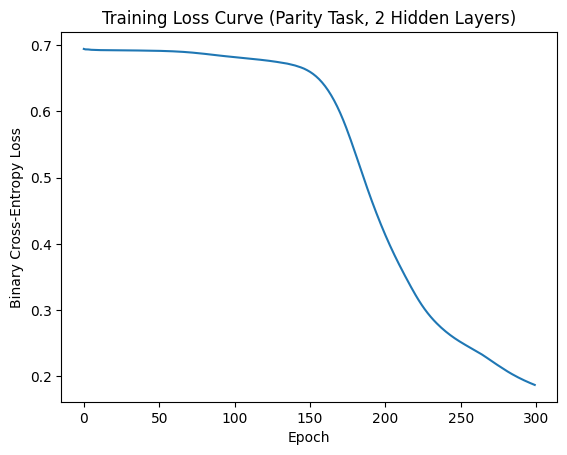

In [ ]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Model Definition (2 hidden layers)
class ParityMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=16, hidden_dim2=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, 1)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        h1 = torch.tanh(self.fc1(x))   # first hidden layer
        h2 = torch.tanh(self.fc2(h1))  # second hidden layer
        out = self.activation(self.fc3(h2))
        return out, (h1, h2)  # return both hidden layers for analysis

# 2. Instantiate Model
model = ParityMLP(input_dim=seq_length, hidden_dim1=16, hidden_dim2=8)
print(model)

# 3. Loss and Optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 4. Training Loop
losses = []
for epoch in range(300):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/300]  Loss: {loss.item():.4f}")

print("Final training loss:", losses[-1])

# 5. Evaluation
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    predicted_labels = (preds > 0.5).float()
    accuracy = (predicted_labels == y_val).float().mean().item()

print(f"Validation Accuracy: {accuracy*100:.2f}%")

# 6. Plot Training Loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Curve (Parity Task, 2 Hidden Layers)")
plt.show()


#### **Part 2 – Explore**

**Activations of a sample input**
- I tested a sample input to observe how it is processed through the model. The results show the activations of both hidden layers and the final output prediction. The first hidden layer showed both strong positive and negative activations, indicating selective responses to different input bits. The second hidden layer exhibited near-saturated tanh values, suggesting that it encodes higher-level, abstract features. The final output of 0.22 correctly classified the input as even parity (0)

In [ ]:
with torch.no_grad():
    # sample input
    sample_input = torch.tensor([[1, 0, 1, 0, 1, 1, 0, 0]], dtype=torch.float32)
    logits, (h1, h2) = model(sample_input)

print(f"Sample Input: {sample_input}")
print(f"Hidden Layer 1 Activations: {h1}")
print(f"Hidden Layer 2 Activations: {h2}")
print(f"Output Logit: {logits}")

# Prediction threshold
pred = (logits > 0.5).float().item()
print(f"Predicted Parity: {int(pred)} (1=Odd, 0=Even)")


Sample Input: tensor([[1., 0., 1., 0., 1., 1., 0., 0.]])
Hidden Layer 1 Activations: tensor([[ 0.9962,  0.8142,  0.6499, -0.9946,  0.8807, -0.7327, -0.8066,  0.7889,
         -0.9963, -0.3947, -0.5646,  0.9802, -0.7077, -0.9560, -0.8460, -0.9591]])
Hidden Layer 2 Activations: tensor([[-0.9999,  1.0000, -0.9997,  0.9997,  0.6201,  0.9999, -1.0000, -0.6502]])
Output Logit: tensor([[0.2216]])
Predicted Parity: 0 (1=Odd, 0=Even)


**Visualize weights**
- The heatmaps show activation values for the first 200 validation samples across neurons in each hidden layer. In the first hidden layer, activations are highly varied across neurons and samples, suggesting diverse local feature extraction.

- The second hidden layer exhibits stronger saturation (near +1 or –1), indicating that neurons have formed more polarized and abstract representations related to parity. This progression from distributed, mixed activations to saturated, high-level patterns suggests hierarchical feature encoding within the network.

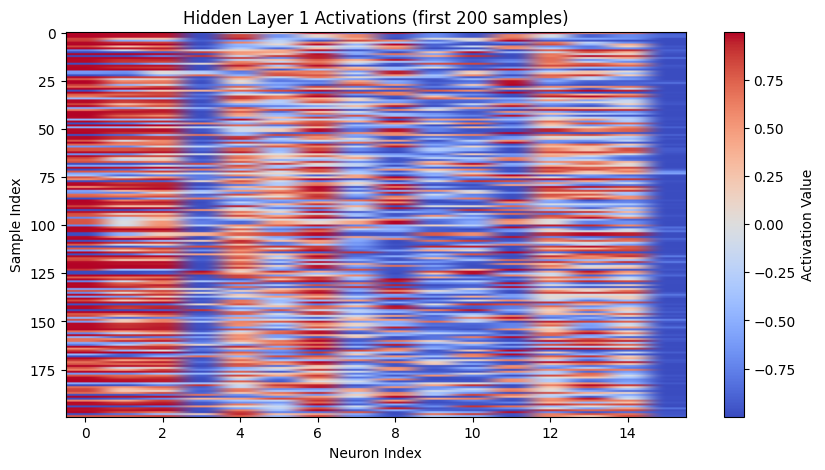

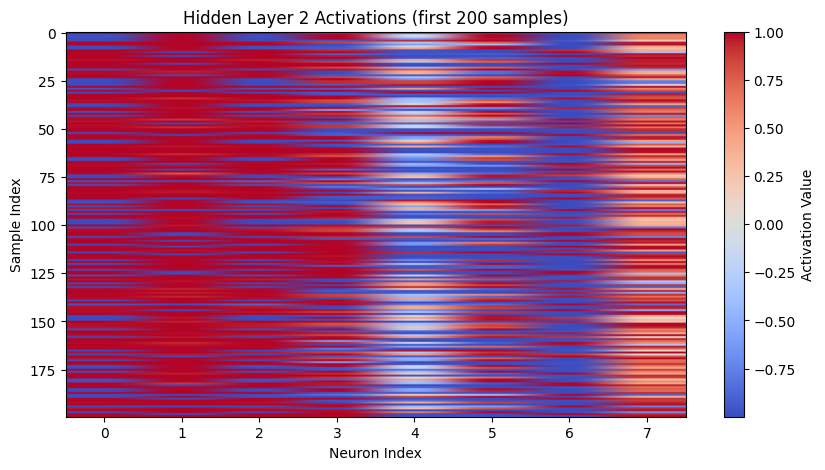

In [ ]:
with torch.no_grad():
    _, (h1, h2) = model(X_val[:200]) #200 samples

# Hidden Layer 1
plt.figure(figsize=(10, 5))
plt.imshow(h1.numpy(), aspect="auto", cmap="coolwarm")
plt.colorbar(label="Activation Value")
plt.title("Hidden Layer 1 Activations (first 200 samples)")
plt.xlabel("Neuron Index")
plt.ylabel("Sample Index")
plt.show()

# Hidden Layer 2
plt.figure(figsize=(10, 5))
plt.imshow(h2.numpy(), aspect="auto", cmap="coolwarm")
plt.colorbar(label="Activation Value")
plt.title("Hidden Layer 2 Activations (first 200 samples)")
plt.xlabel("Neuron Index")
plt.ylabel("Sample Index")
plt.show()


**Average Activation by Class**

Based on the heatmap, I analyzed how neurons in the second hidden layer respond differently to even and odd inputs. Neurons 0–3 function as strong even-sensitive units, showing consistently high positive activation when the input belongs to the even class. In contrast, Neurons 4–6 show negative activation patterns, serving as suppressive units that respond more strogly to odd inputs. Neuron 7 remains relatively neutral, likely contributing to general feature smoothing rather than class discrimination.

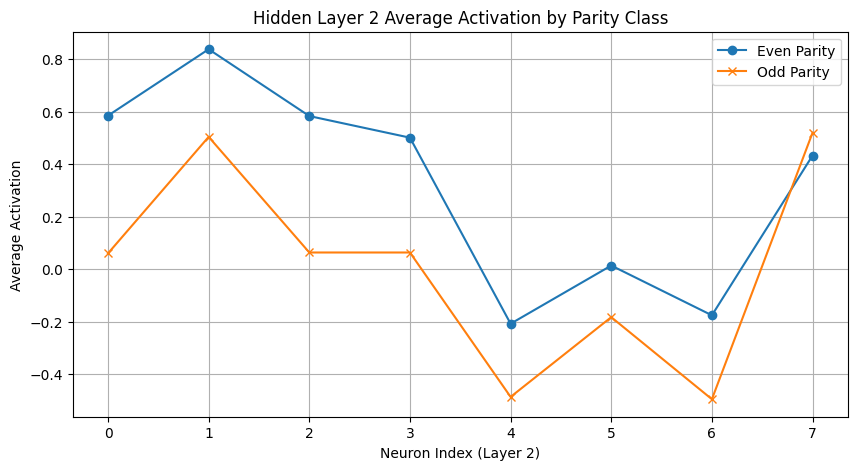

Neuron      Even Avg     Odd Avg    Δ(odd-even)
0              0.585       0.060         -0.525
1              0.838       0.504         -0.334
2              0.583       0.064         -0.520
3              0.501       0.064         -0.437
4             -0.208      -0.486         -0.279
5              0.014      -0.183         -0.197
6             -0.176      -0.495         -0.320
7              0.433       0.520          0.087


In [ ]:
with torch.no_grad():
    _, (h1, h2) = model(X_val)

even_mask = (y_val.squeeze() == 0)
odd_mask = (y_val.squeeze() == 1)

avg_even = h2[even_mask].mean(dim=0)
avg_odd = h2[odd_mask].mean(dim=0)

plt.figure(figsize=(10, 5))
plt.plot(avg_even.numpy(), label="Even Parity", marker='o')
plt.plot(avg_odd.numpy(), label="Odd Parity", marker='x')
plt.xlabel("Neuron Index (Layer 2)")
plt.ylabel("Average Activation")
plt.title("Hidden Layer 2 Average Activation by Parity Class")
plt.legend()
plt.grid(True)
plt.show()

with torch.no_grad():
    _, (h1, h2) = model(X_val)

# Define masks
even_mask = (y_val.squeeze() == 0)
odd_mask = (y_val.squeeze() == 1)

# Compute average activations
avg_even = h2[even_mask].mean(dim=0)
avg_odd = h2[odd_mask].mean(dim=0)

# Print coordinates (neuron index, even activation, odd activation, difference)
print(f"{'Neuron':<8}{'Even Avg':>12}{'Odd Avg':>12}{'Δ(odd-even)':>15}")
for i in range(h2.shape[1]):
    even_val = avg_even[i].item()
    odd_val = avg_odd[i].item()
    diff = odd_val - even_val
    print(f"{i:<8}{even_val:>12.3f}{odd_val:>12.3f}{diff:>15.3f}")


**Neuron Ablation Test**
- This ablation experiment measures how the output probability shifts when individual neurons are deactivated, showing that Layer 1 functions as a distributed feature encoder, Layer 2 holds the neurons driving the parity decision, and the sign of Δ indicates whether each neuron supports or stabilizes the prediction.

In [ ]:
#Test code#
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)

model.eval()
with torch.no_grad():
    baseline_output, (h1, h2) = model(test_input)
    baseline_pred = (baseline_output > 0.5).float().item()

print(f"Baseline Prediction: {baseline_pred:.0f}")

# Single Neuron Ablation (1 hidden layer neuron)
neuron_to_zero = 2
with torch.no_grad():
    h1_mod = h1.clone()
    h1_mod[:, neuron_to_zero] = 0  # zero this neuron
    h2_mod = torch.tanh(model.fc2(h1_mod))
    out_mod = model.activation(model.fc3(h2_mod))
    mod_pred = (out_mod > 0.5).float().item()

print(f"Modified Prediction (Neuron {neuron_to_zero} zeroed): {mod_pred:.0f}")


Baseline Prediction: 0
Modified Prediction (Neuron 2 zeroed): 0


**Neuron Ablation Sweep**
- This ablation experiment measures how the output probability changes when individual neurons are deactivated, revealing that Layer 1 functions as a distributed feature encoder while Layer 2 contains the neurons directly responsible for the parity decision.

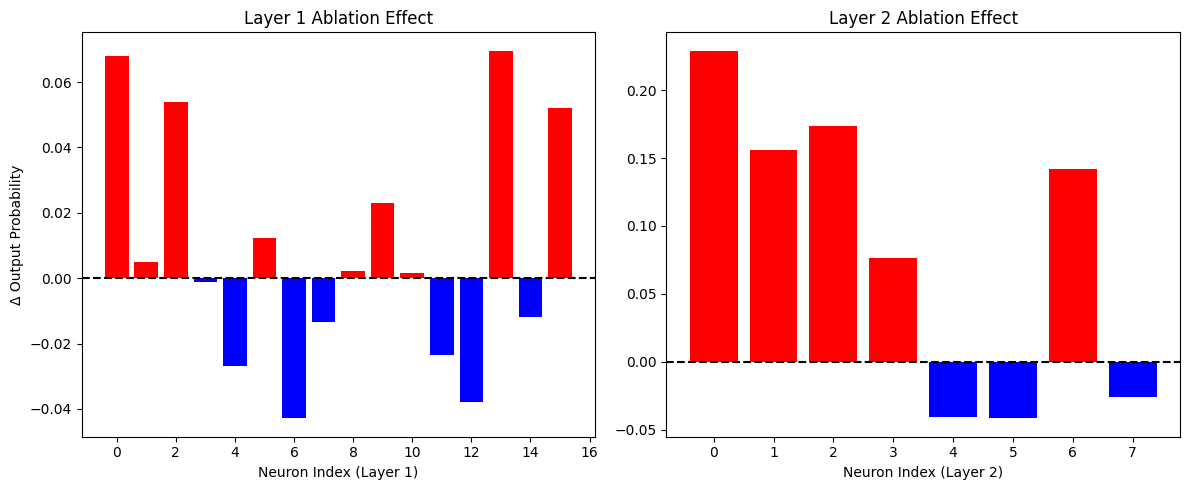

=== Layer 1 Neuron Effects ===
Neuron 0: Δ = +0.068
Neuron 1: Δ = +0.005
Neuron 2: Δ = +0.054
Neuron 3: Δ = -0.001
Neuron 4: Δ = -0.027
Neuron 5: Δ = +0.012
Neuron 6: Δ = -0.043
Neuron 7: Δ = -0.013
Neuron 8: Δ = +0.002
Neuron 9: Δ = +0.023
Neuron 10: Δ = +0.001
Neuron 11: Δ = -0.024
Neuron 12: Δ = -0.038
Neuron 13: Δ = +0.070
Neuron 14: Δ = -0.012
Neuron 15: Δ = +0.052

=== Layer 2 Neuron Effects ===
Neuron 0: Δ = +0.229
Neuron 1: Δ = +0.156
Neuron 2: Δ = +0.174
Neuron 3: Δ = +0.076
Neuron 4: Δ = -0.040
Neuron 5: Δ = -0.042
Neuron 6: Δ = +0.142
Neuron 7: Δ = -0.026


In [ ]:
import matplotlib.pyplot as plt
import torch

# Baseline output
with torch.no_grad():
    baseline_output, (h1, h2) = model(test_input)
    baseline_val = baseline_output.item()

# Layer 1 Ablation
neuron_indices_L1 = list(range(model.fc1.out_features))
signed_deltas_L1 = []

for i in neuron_indices_L1:
    with torch.no_grad():
        h1_mod = h1.clone()
        h1_mod[:, i] = 0
        h2_mod = torch.tanh(model.fc2(h1_mod))
        out_mod = model.activation(model.fc3(h2_mod))
        delta = out_mod.item() - baseline_val
        signed_deltas_L1.append(delta)

# Layer 2 Ablation
neuron_indices_L2 = list(range(model.fc2.out_features))
signed_deltas_L2 = []

for j in neuron_indices_L2:
    with torch.no_grad():
        h1_mod = torch.tanh(model.fc1(test_input))
        h2_mod = torch.tanh(model.fc2(h1_mod))
        h2_mod[:, j] = 0
        out_mod = model.activation(model.fc3(h2_mod))
        delta = out_mod.item() - baseline_val
        signed_deltas_L2.append(delta)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(neuron_indices_L1, signed_deltas_L1,
        color=['red' if d > 0 else 'blue' for d in signed_deltas_L1])
plt.axhline(0, color='black', linestyle='--')
plt.title("Layer 1 Ablation Effect")
plt.xlabel("Neuron Index (Layer 1)")
plt.ylabel("Δ Output Probability")

plt.subplot(1, 2, 2)
plt.bar(neuron_indices_L2, signed_deltas_L2,
        color=['red' if d > 0 else 'blue' for d in signed_deltas_L2])
plt.axhline(0, color='black', linestyle='--')
plt.title("Layer 2 Ablation Effect")
plt.xlabel("Neuron Index (Layer 2)")

plt.tight_layout()
plt.show()

print("=== Layer 1 Neuron Effects ===")
for i, d in enumerate(signed_deltas_L1):
    if abs(d) > 1e-3:
        print(f"Neuron {i}: Δ = {d:+.3f}")

print("\n=== Layer 2 Neuron Effects ===")
for j, d in enumerate(signed_deltas_L2):
    if abs(d) > 1e-3:
        print(f"Neuron {j}: Δ = {d:+.3f}")


#### **Part 3 – Explain**

- When I look at the hidden activations, I notice that the neurons in the second hidden layer take on clearly different roles. Neurons 0–3 respond strongly and positively to even inputs, so they act as “even detectors.” In contrast, neurons 4–6 respond negatively to odd inputs, making them “odd-sensitive” units. This shows that the second layer turns the distributed information from earlier layers into a clearer boundary for deciding parity.

- Comparing the average activations for even and odd samples supports this idea. The even-sensitive neurons become more active for even inputs, while the odd-sensitive neurons show lower or negative activations for odd inputs. Instead of counting numbers directly, the model expresses parity through the sign of these activations. Each neuron adds a small piece of information, and together they guide the final prediction.

- The ablation tests make this structure even more apparent. When I deactivate neurons one by one, the second layer influences the output far more than the first layer, meaning most of the decision-making happens there. Some neurons cause a clear drop in confidence when removed, showing that they are essential for detecting parity. Overall, even this small MLP develops an organized and interpretable internal process for solving the parity task.

#### **Part 4 – Reflect**

**What did you learn about how your model works?**
- I learned that the model builds the parity rule through a two-step process: the first layer creates distributed nonlinear features, and the second layer turns those features into a clear even–odd decision using specialized neurons

**What was confusing, surprising, or challenging to interpret?**
- I was surprised that the second layer develops such clean “even” and “odd” detectors on its own. The first layer, however, is harder to interpret because its activations are highly mixed and don’t show clear patterns.

**What’s one thing you wish you could understand better or explore further?**
- I want to explore whether the neuron-level structure I observed is consistent across different random seeds. Although the current analysis fixes the seed(=42) for reproducibility, it would be interesting to train the model multiple times and test whether the same layer-wise roles and activation patterns reliably emerge. This would show whether the model’s internal organization is truly general or just a seed-specific artifact.